In [2]:
# 01_eda_initial.py

%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Hardcoded absolute path to bypass any notebook folder path traps
PROJECT_ROOT = '/Users/abannee/Documents/GitHub/fraud_detection_ml/'

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.data_utils import load_and_merge_data
from src.data_utils import engineer_time_features





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. First, tell Python exactly where to look for your project modules
PROJECT_ROOT = '/Users/abannee/Documents/GitHub/fraud_detection_ml/'

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# 2. Now that the path is set, you can safely import your custom functions
from src.data_utils import load_and_merge_data, engineer_time_features

In [3]:
DATA_DIR = os.path.join(PROJECT_ROOT, 'data/raw')
TRAIN_TXN = os.path.join(DATA_DIR, 'train_transaction.csv')
TRAIN_ID = os.path.join(DATA_DIR, 'train_identity.csv')

df = load_and_merge_data(TRAIN_TXN, TRAIN_ID)

Loading transaction dataset...
Loading identity dataset...
Executing defensive Left-Merge across TransactionID fields...
Memory usage of dataframe is 1984.20 MB
Memory usage after optimization is: 1073.53 MB
Decreased by 45.9%



--- Visualizing Target Distribution (Class Imbalance) ---


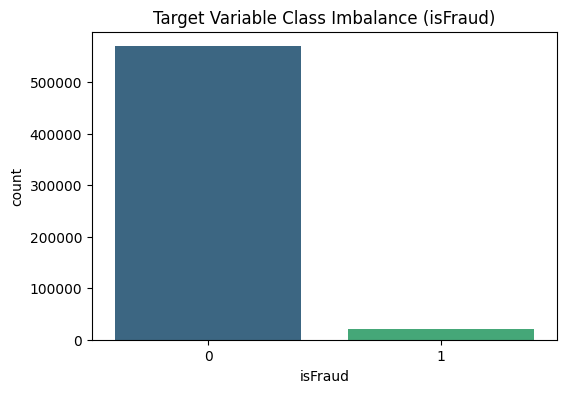

Total Records: 590540 | Total Fraud: 20663 (3.50%)


In [4]:
print("\n--- Visualizing Target Distribution (Class Imbalance) ---")
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df, hue='isFraud', palette='viridis', legend=False)
# sns.countplot(x='isFraud', data=df, palette='viridis')
plt.title('Target Variable Class Imbalance (isFraud)')
plt.show()
plt.xlabel('Is Fraudulent?')
plt.ylabel('Transaction Count')
# Print raw rates onto console for validation tracking
fraud_pct = (df['isFraud'].sum() / len(df)) * 100
print(f"Total Records: {len(df)} | Total Fraud: {df['isFraud'].sum()} ({fraud_pct:.2f}%)")
plt.savefig('plots/01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.close()


--- Generating Clean Missing Value Insight Matrix ---


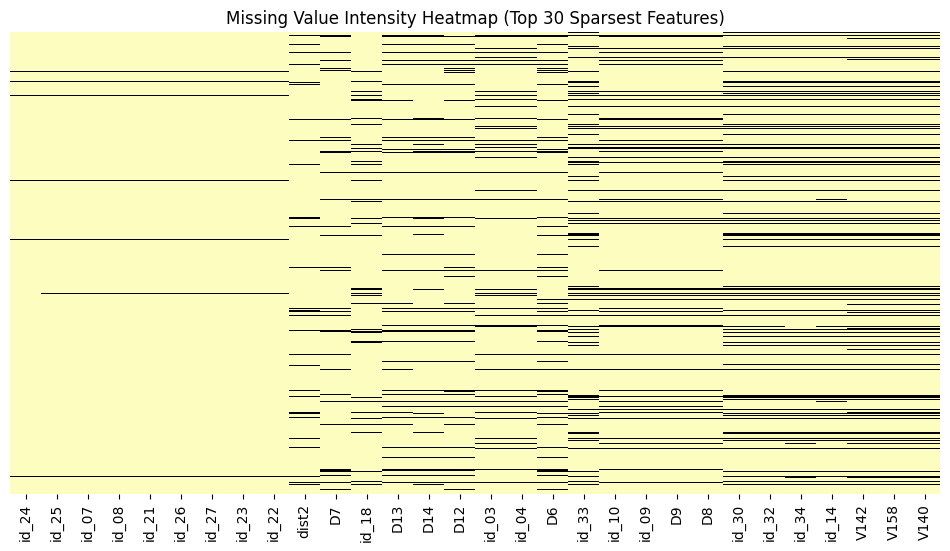

In [5]:
print("\n--- Generating Clean Missing Value Insight Matrix ---")
# To avoid memory OOM crash on 400+ columns heatmap, isolate the top 30 features with the highest null volume
missing_props = df.isnull().mean().sort_values(ascending=False).head(30)
missing_df = df[missing_props.index].sample(n=10000, random_state=42) # Sample to avoid matrix rendering lag

plt.figure(figsize=(12, 6))
sns.heatmap(missing_df.isnull(), cbar=False, cmap='magma', yticklabels=False)
plt.title('Missing Value Intensity Heatmap (Top 30 Sparsest Features)')
plt.xticks(rotation=90)
plt.show()
plt.savefig('plots/02_missing_value_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()


--- Visualizing Transaction Amount Distributions ---


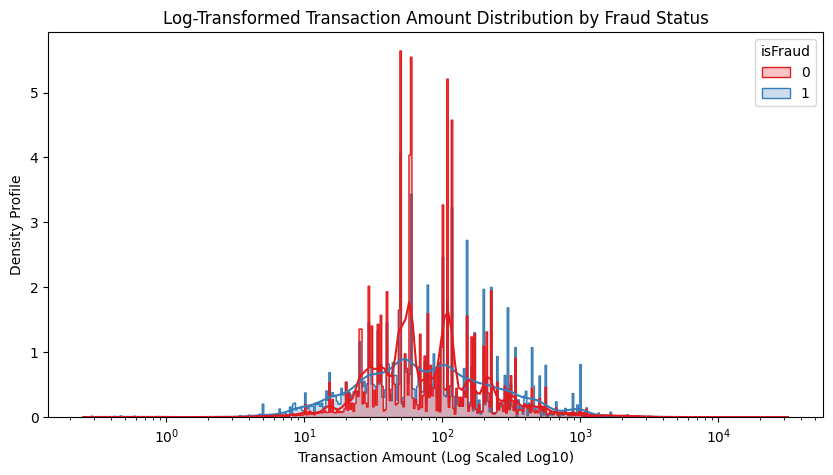

Initial Exploratory Phase Complete! Figures written successfully to 'plots/'.


In [6]:
print("\n--- Visualizing Transaction Amount Distributions ---")
plt.figure(figsize=(10, 5))
# Use log scale transformation to isolate heavily skewed transaction quantities cleanly
sns.histplot(data=df, x='TransactionAmt', hue='isFraud', kde=True, log_scale=True, element='step', stat='density', common_norm=False, palette='Set1')
plt.title('Log-Transformed Transaction Amount Distribution by Fraud Status')
plt.xlabel('Transaction Amount (Log Scaled Log10)')
plt.ylabel('Density Profile')
plt.show()
plt.savefig('plots/03_transaction_amt_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

print("Initial Exploratory Phase Complete! Figures written successfully to 'plots/'.")


--- Plotting Feature Correlation Core Heatmap ---


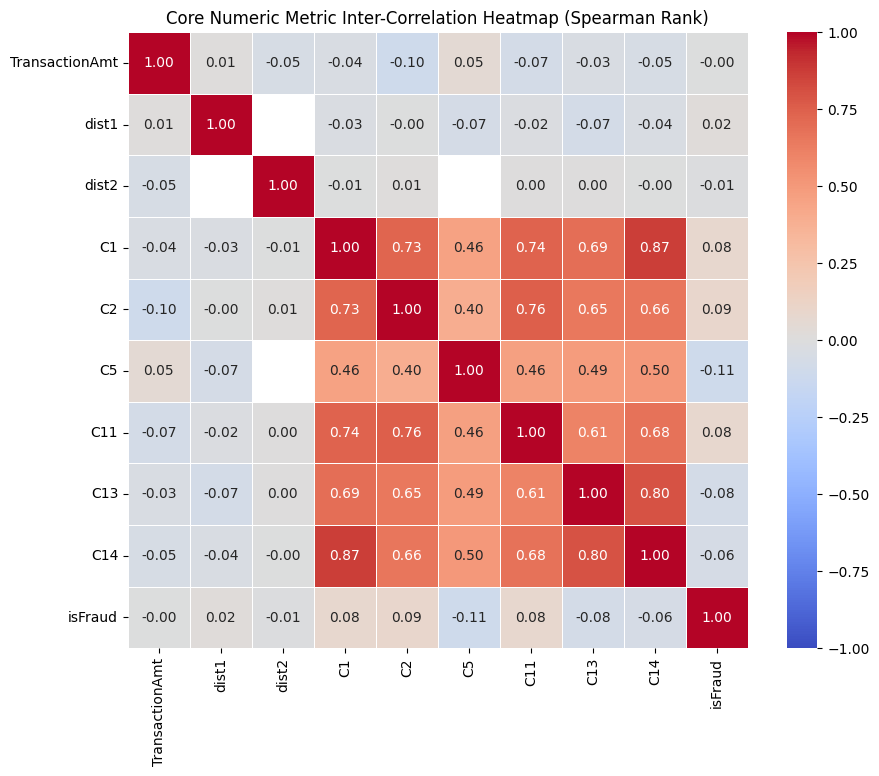

In [11]:
df = engineer_time_features(df)

print("\n--- Plotting Feature Correlation Core Heatmap ---")
# Focus on core numeric features known to contain heavy signal variance
core_numerical_cols = ['TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C5', 'C11', 'C13', 'C14', 'isFraud']
corr_matrix = df[core_numerical_cols].corr(method='spearman') # Spearman handles outliers safely

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Core Numeric Metric Inter-Correlation Heatmap (Spearman Rank)')
plt.show()
plt.savefig('plots/04_core_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()


--- Evaluating Vesta Column Cluster Vectors ---


/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_74795/436147926.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='isFraud', y=col, ax=axes[idx], palette='Set2')
/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_74795/436147926.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='isFraud', y=col, ax=axes[idx], palette='Set2')
/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_74795/436147926.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='isFraud', y=col, ax=axes[idx], palet

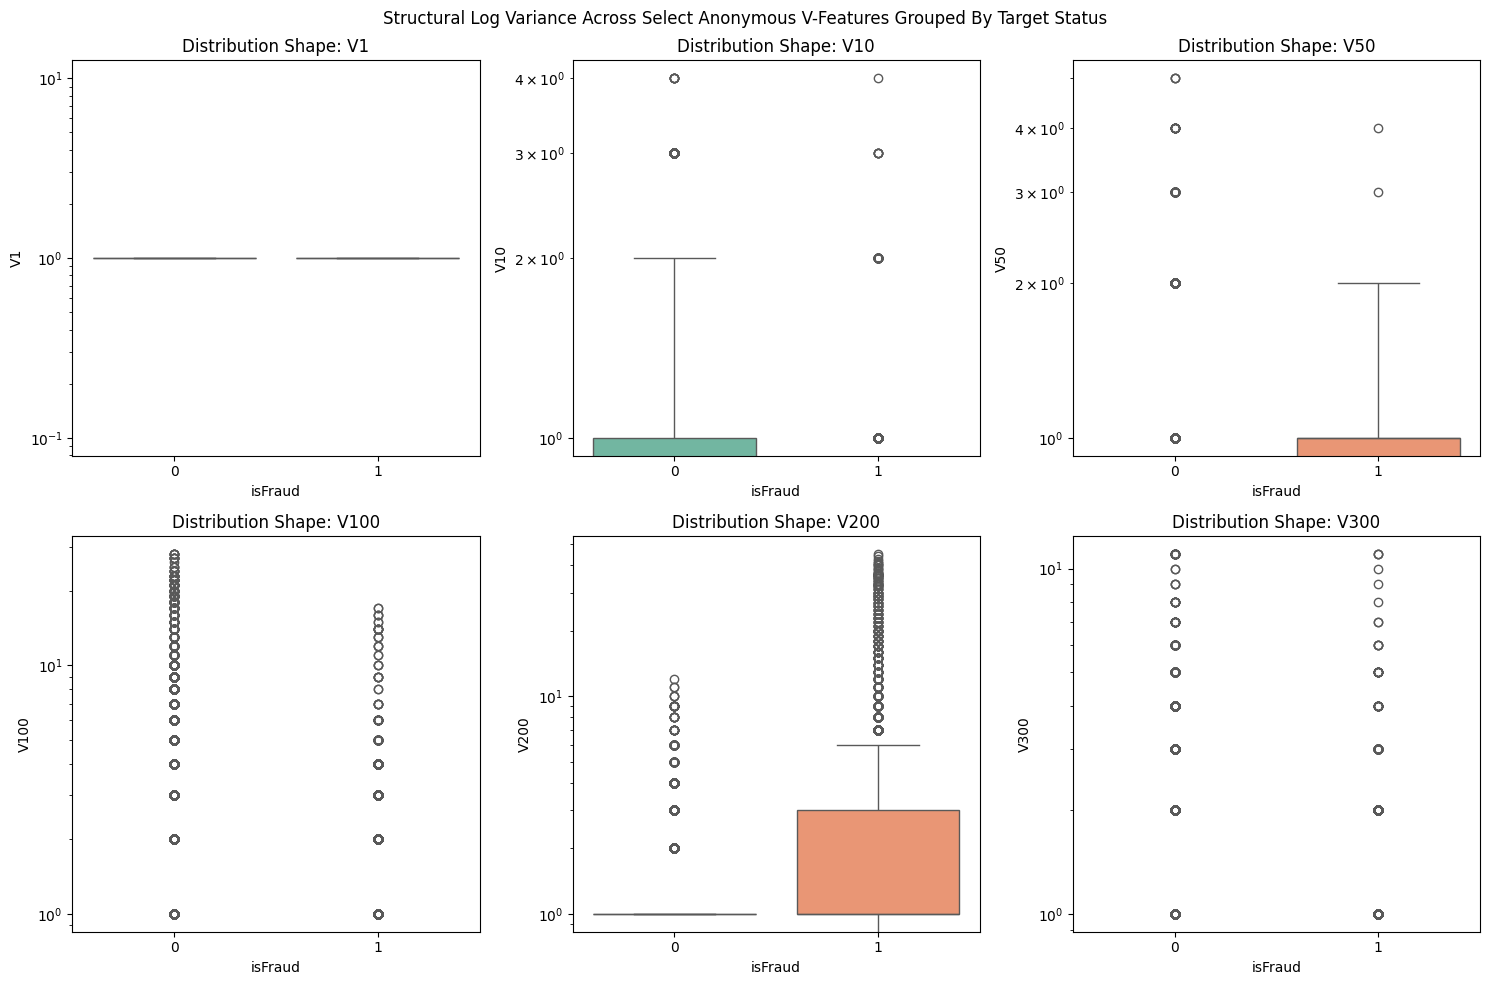

In [12]:
print("\n--- Evaluating Vesta Column Cluster Vectors ---")
# Isolate a structural cross section of anonymous 'V' columns
v_cols_sample = ['V1', 'V10', 'V50', 'V100', 'V200', 'V300']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(v_cols_sample):
    sns.boxplot(data=df, x='isFraud', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'Distribution Shape: {col}')
    axes[idx].set_yscale('log') # Structural variance is best isolated on log distributions
plt.suptitle('Structural Log Variance Across Select Anonymous V-Features Grouped By Target Status')
plt.tight_layout()
plt.show()
plt.savefig('plots/05_v_columns_distribution.png', dpi=150, bbox_inches='tight')
plt.close()



--- Mapping Fraud Velocities Over Time Arrays ---


/var/folders/2w/c8v4yt5j21s3nkv8j9x_fc340000gn/T/ipykernel_74795/2706467669.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])


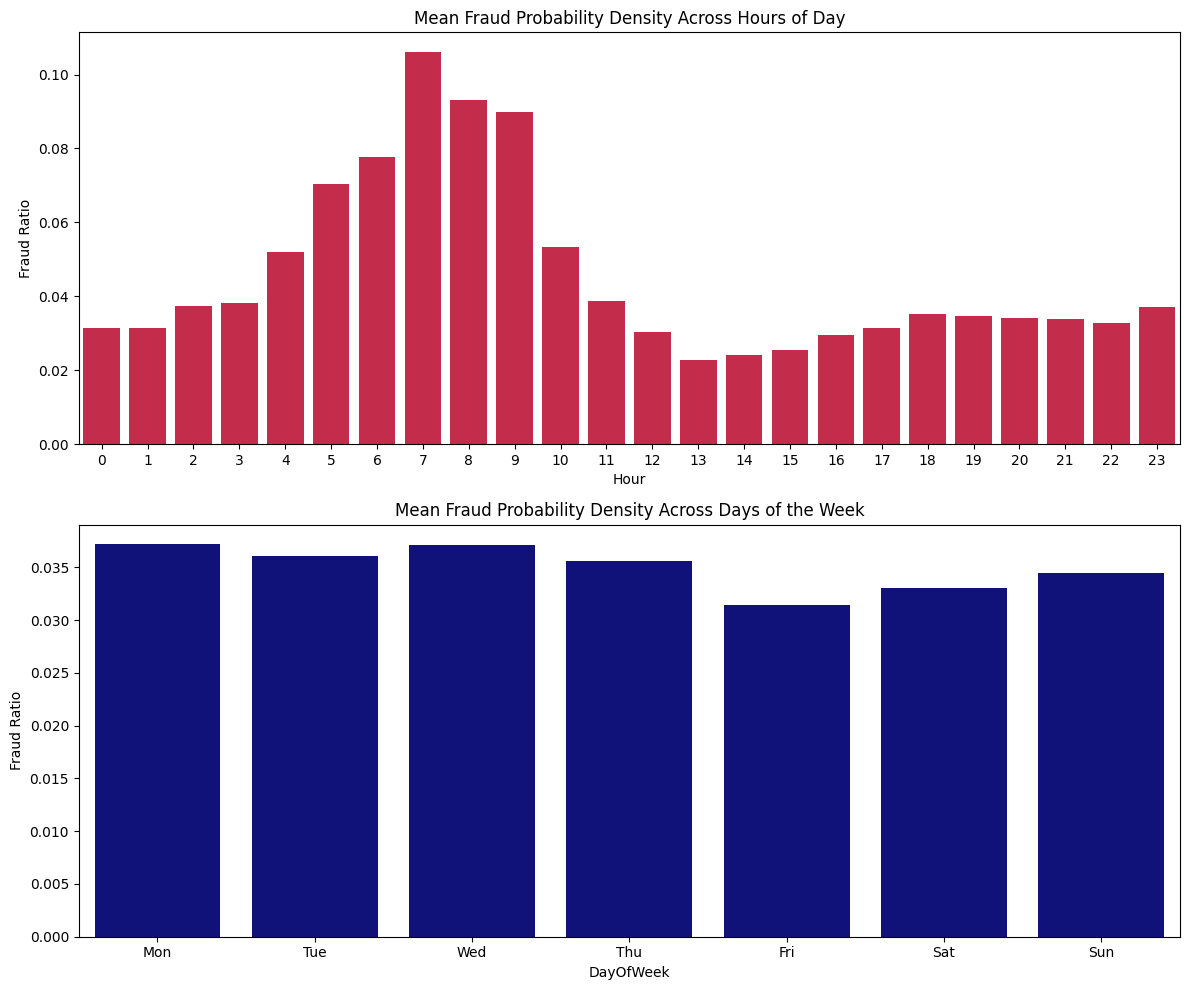

Advanced Exploratory Phase Complete!


In [13]:
print("\n--- Mapping Fraud Velocities Over Time Arrays ---")
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Hourly Trend Lookups
hourly_fraud = df.groupby('Hour')['isFraud'].mean().reset_index()
sns.barplot(data=hourly_fraud, x='Hour', y='isFraud', ax=axes[0], color='crimson')
axes[0].set_title('Mean Fraud Probability Density Across Hours of Day')
axes[0].set_ylabel('Fraud Ratio')

# 2. Weekday Variation Lookups
weekday_fraud = df.groupby('DayOfWeek')['isFraud'].mean().reset_index()
sns.barplot(data=weekday_fraud, x='DayOfWeek', y='isFraud', ax=axes[1], color='darkblue')
axes[1].set_title('Mean Fraud Probability Density Across Days of the Week')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_ylabel('Fraud Ratio')

plt.tight_layout()
plt.show()
plt.savefig('plots/06_temporal_fraud_patterns.png', dpi=150, bbox_inches='tight')
plt.close()

print("Advanced Exploratory Phase Complete!")

### 15-06-2026

In [ ]:
# 02_eda_advanced.py
# import os
# import matplotlib.pyplot as plt
# import seaborn as sns
# import gc
# from src.data_utils import load_and_merge_data, engineer_time_features

# TRAIN_TXN = 'data/train_transaction.csv'
# TRAIN_ID = 'data/train_identity.csv'

# df = load_and_merge_data(TRAIN_TXN, TRAIN_ID)
# df = engineer_time_features(df)

# print("\n--- Plotting Feature Correlation Core Heatmap ---")
# # Focus on core numeric features known to contain heavy signal variance
# core_numerical_cols = ['TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C5', 'C11', 'C13', 'C14', 'isFraud']
# corr_matrix = df[core_numerical_cols].corr(method='spearman') # Spearman handles outliers safely

# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
# plt.title('Core Numeric Metric Inter-Correlation Heatmap (Spearman Rank)')
# plt.savefig('plots/04_core_correlation_heatmap.png', dpi=150, bbox_inches='tight')
# plt.close()

# print("\n--- Evaluating Vesta Column Cluster Vectors ---")
# # Isolate a structural cross section of anonymous 'V' columns
# v_cols_sample = ['V1', 'V10', 'V50', 'V100', 'V200', 'V300']
# fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# axes = axes.flatten()

# for idx, col in enumerate(v_cols_sample):
#     sns.boxplot(data=df, x='isFraud', y=col, ax=axes[idx], palette='Set2')
#     axes[idx].set_title(f'Distribution Shape: {col}')
#     axes[idx].set_yscale('log') # Structural variance is best isolated on log distributions
# plt.suptitle('Structural Log Variance Across Select Anonymous V-Features Grouped By Target Status')
# plt.tight_layout()
# plt.savefig('plots/05_v_columns_distribution.png', dpi=150, bbox_inches='tight')
# plt.close()

# print("\n--- Mapping Fraud Velocities Over Time Arrays ---")
# fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# # 1. Hourly Trend Lookups
# hourly_fraud = df.groupby('Hour')['isFraud'].mean().reset_index()
# sns.barplot(data=hourly_fraud, x='Hour', y='isFraud', ax=axes[0], color='crimson')
# axes[0].set_title('Mean Fraud Probability Density Across Hours of Day')
# axes[0].set_ylabel('Fraud Ratio')

# # 2. Weekday Variation Lookups
# weekday_fraud = df.groupby('DayOfWeek')['isFraud'].mean().reset_index()
# sns.barplot(data=weekday_fraud, x='DayOfWeek', y='isFraud', ax=axes[1], color='darkblue')
# axes[1].set_title('Mean Fraud Probability Density Across Days of the Week')
# axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
# axes[1].set_ylabel('Fraud Ratio')

# plt.tight_layout()
# plt.savefig('plots/06_temporal_fraud_patterns.png', dpi=150, bbox_inches='tight')
# plt.close()

# print("Advanced Exploratory Phase Complete!")

In [ ]:
# # 01_eda_initial.py
# import os
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# from src.data_utils import load_and_merge_data

# # Configurations
# TRAIN_TXN = 'data/train_transaction.csv'
# TRAIN_ID = 'data/train_identity.csv'
# os.makedirs('plots', exist_ok=True)

# # Load data
# df = load_and_merge_data(TRAIN_TXN, TRAIN_ID)

# print("\n--- Visualizing Target Distribution (Class Imbalance) ---")
# plt.figure(figsize=(6, 4))
# sns.countplot(x='isFraud', data=df, palette='viridis')
# plt.title('Target Variable Class Imbalance (isFraud)')
# plt.xlabel('Is Fraudulent?')
# plt.ylabel('Transaction Count')
# # Print raw rates onto console for validation tracking
# fraud_pct = (df['isFraud'].sum() / len(df)) * 100
# print(f"Total Records: {len(df)} | Total Fraud: {df['isFraud'].sum()} ({fraud_pct:.2f}%)")
# plt.savefig('plots/01_class_imbalance.png', dpi=150, bbox_inches='tight')
# plt.close()

# print("\n--- Generating Clean Missing Value Insight Matrix ---")
# # To avoid memory OOM crash on 400+ columns heatmap, isolate the top 30 features with the highest null volume
# missing_props = df.isnull().mean().sort_values(ascending=False).head(30)
# missing_df = df[missing_props.index].sample(n=10000, random_state=42) # Sample to avoid matrix rendering lag

# plt.figure(figsize=(12, 6))
# sns.heatmap(missing_df.isnull(), cbar=False, cmap='magma', yticklabels=False)
# plt.title('Missing Value Intensity Heatmap (Top 30 Sparsest Features)')
# plt.xticks(rotation=90)
# plt.savefig('plots/02_missing_value_heatmap.png', dpi=150, bbox_inches='tight')
# plt.close()

# print("\n--- Visualizing Transaction Amount Distributions ---")
# plt.figure(figsize=(10, 5))
# # Use log scale transformation to isolate heavily skewed transaction quantities cleanly
# sns.histplot(data=df, x='TransactionAmt', hue='isFraud', kde=True, log_scale=True, element='step', stat='density', common_norm=False, palette='Set1')
# plt.title('Log-Transformed Transaction Amount Distribution by Fraud Status')
# plt.xlabel('Transaction Amount (Log Scaled Log10)')
# plt.ylabel('Density Profile')
# plt.savefig('plots/03_transaction_amt_distribution.png', dpi=150, bbox_inches='tight')
# plt.close()

# print("Initial Exploratory Phase Complete! Figures written successfully to 'plots/'.")